# Knee Injuries Classification Project
## MRNet Classifier Notebook 

### Data source: 
#### Stanford AIMI. (2026). MRNet: Knee MRI's (Version 1.0) [Dataset]. Redivis. https://stanford.redivis.com/datasets/4a2c-4cpkzrn2c?v=1.0


In [2]:
# MRNet Environment Setup (Run this cell first)
from google.colab import drive
import sys
import os
import zipfile
import shutil

### Only use the following code when you want to add the zipped folder to your drive.
This might take up to 40 minutes to run but it is a one time thing. If you can somehow create the .zip folder in your drive than you do not need to run this code. 

In [ ]:
drive.mount('/content/drive')
# 1. Define paths
# SOURCE: Your mounted Google Drive folder
# since you might have the files in a subfolder, make sure to create a folder shortcut in your Drive for easier access
shared_folder_path = '/content/drive/MyDrive/mrnet_images' 

# DESTINATION: The local, ultra-fast Colab cloud SSD storage
local_zip_path = '/content/mrnet_images.zip'

print("Starting optimized compression onto local cloud SSD...")

# 2. Zip from Drive directly to the local cloud SSD
!zip -rq "{local_zip_path}" "{shared_folder_path}"

print("Compression to local SSD complete! Now uploading the single file back to your Drive...")

# 3. Copy the single large zip back to Google Drive in one efficient burst
!cp "{local_zip_path}" "/content/drive/MyDrive/"

print("All done! Your optimized 'mrnet_images.zip' is now saved in your Google Drive.")

### Loading data into colab SSD 
When we already have your zip folder, we can start from here to git the data unziped inside the colab SSD. 

In [3]:
# 1. Mount persistent storage
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:

# Define our paths clearly
zip_source = '/content/drive/MyDrive/mrnet_images.zip'
zip_local = '/content/mrnet_images.zip'
extract_to = '/content/'

# 2. Run extraction sequence if data isn't unpacked yet
if not os.path.exists('/content/mrnet_images'):
    
    # Step A: Copy the zip from Drive to local SSD if it's missing
    if not os.path.exists(zip_local):
        print("Transferring optimized archive from Drive to local cloud SSD...")
        shutil.copy(zip_source, zip_local)
        print("Transfer complete! Starting extraction...")
        
    # Step B: Unzip with the visible progress counter
    print("Opening zip archive securely...")
    with zipfile.ZipFile(zip_local, 'r') as zip_ref:
        files = zip_ref.namelist()
        total_files = len(files)
        print(f"Total files to extract: {total_files}")
        
        for index, file in enumerate(files):
            zip_ref.extract(file, extract_to)
            if index % 500 == 0 and index > 0:
                print(f"-> Extracted {index}/{total_files} files... ({int(index/total_files*100)}%)")
                
    print("Unpacking complete!")
    
    # Step C: Fix the path nesting structure automatically
    if os.path.exists('/content/content/drive/MyDrive/mrnet_images'):
        print("Correcting zip path nesting structure...")
        os.rename('/content/content/drive/MyDrive/mrnet_images', '/content/mrnet_images')
        shutil.rmtree('/content/content')
        
    # Step D: Clean up the local zip file to save SSD space
    if os.path.exists(zip_local):
        os.remove(zip_local)
        
    print("Environment Setup Perfected!")
else:
    print("Data already unpacked and ready on local SSD.")

Transferring optimized archive from Drive to local cloud SSD...
Transfer complete! Starting extraction...
Opening zip archive securely...
Total files to extract: 3580
-> Extracted 500/3580 files... (13%)
-> Extracted 1000/3580 files... (27%)
-> Extracted 1500/3580 files... (41%)
-> Extracted 2000/3580 files... (55%)
-> Extracted 2500/3580 files... (69%)
-> Extracted 3000/3580 files... (83%)
-> Extracted 3500/3580 files... (97%)
Unpacking complete!
Correcting zip path nesting structure...
Environment Setup Perfected!


### Importing .py file

In [5]:
import importlib
# 1. Clone the repository if it doesn't exist on the cloud machine yet
repo_path = '/content/CNN_ClassModeling'

if not os.path.exists(repo_path):
    print("Cloning the code repository from GitHub...")
    !git clone https://github.com/AbdulAlbaqami/Knee_Injuries_Classification_Model_MRI_Images.git {repo_path}
else:
    print("Repository already exists. Pulling latest updates...")
    !cd {repo_path} && git pull

# 2. Inject the repository path into Python's system search path
if repo_path not in sys.path:
    sys.path.append(repo_path)

# 3. Safe Module Import / Reload Logic
import loading_data as ld
# If teammates update the file and you pull it, this line forces Python to update its cache
importlib.reload(ld)

print("Successfully imported loading_data.py module!")

Cloning the code repository from GitHub...
Cloning into '/content/CNN_ClassModeling'...
remote: Enumerating objects: 42, done.
remote: Counting objects: 100% (42/42), done.
remote: Compressing objects: 100% (33/33), done.
remote: Total 42 (delta 15), reused 32 (delta 8), pack-reused 0 (from 0)
Receiving objects: 100% (42/42), 1001.70 KiB | 18.55 MiB/s, done.
Resolving deltas: 100% (15/15), done.
Successfully imported loading_data.py module!


In [6]:
import numpy as np

# Load a single case 
sample_volume = np.load('/content/mrnet_images/axial/0001.npy')

print("Data Type:", type(sample_volume))
print("Volume Shape:", sample_volume.shape)

Data Type: <class 'numpy.ndarray'>
Volume Shape: (30, 256, 256)


Array Shape: (26, 256, 256)


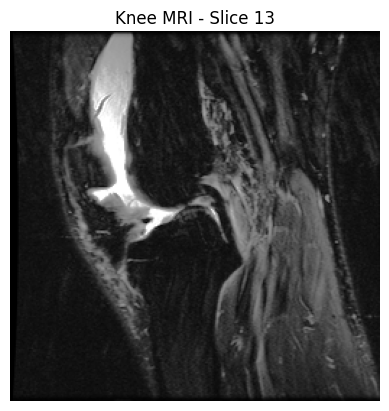

In [7]:
import matplotlib.pyplot as plt

# 1. Load one of your downloaded files (replace with your actual file path)
# Let's grab a random one from your sagittal or axial folder
mri_volume = np.load('/content/mrnet_images/sagittal/0001.npy')

# 2. Check its dimensions
print("Array Shape:", mri_volume.shape)

# 3. Visualize a slice from the middle of the stack
middle_slice_idx = mri_volume.shape[0] // 2

plt.imshow(mri_volume[middle_slice_idx], cmap="gray")
plt.axis("off")
plt.title(f"Knee MRI - Slice {middle_slice_idx}")
plt.show()

### labels Data EDA

In [8]:
import pandas as pd
label_data = pd.read_csv("/content/mrnet_images/labels/Redivis-files-2026-05-18.csv")
print(label_data.head())
print(label_data.columns)
print(label_data["Folder"].value_counts())
print(label_data.describe())


             Name Folder
0  axial/0000.npy  train
1  axial/0001.npy  train
2  axial/0002.npy  train
3  axial/0003.npy  train
4  axial/0004.npy  train
Index(['Name', 'Folder'], dtype='object')
Folder
train    3390
valid     360
Name: count, dtype: int64
                     Name Folder
count                3750   3750
unique               3750      2
top     sagittal/1249.npy  train
freq                    1   3390


In [9]:
label_df = pd.read_csv("/content/CNN_ClassModeling/unified_labels.csv")
print(label_df.head())

   Unnamed: 0  exam_id  abnormal  acl  meniscus  split
0           1     1027         0    0         0  train
1           2      228         0    0         0  train
2           3     1053         1    0         1  train
3           4     1069         1    0         0  train
4           5      278         1    0         0  train


# MOdeling: 
## 1 Multi-Task Model

### Environment Orchestration & Data Loading

In [10]:
import torch
import torch.nn as nn
from torchvision import models
import torch.optim as optim
from sklearn.metrics import roc_auc_score
import numpy as np

# Hardware Selection
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Active compute device: {device}")

# Map the exact paths created by your extraction and Git clone scripts
CLOUD_DATA_ROOT = '/content/mrnet_images'
CLOUD_LABEL_PATH = '/content/CNN_ClassModeling/unified_labels.csv'

# Initialize the factory
train_loader, valid_loader = ld.get_data_loaders(CLOUD_DATA_ROOT, CLOUD_LABEL_PATH, view='sagittal', batch_size=1)
print("Data pipeline linked and ready.")

Active compute device: cuda
Data pipeline linked and ready.


### The Multi-Task Baseline Architecture (Tier 1)

In [11]:
class MRNetBaseline(nn.Module):
    def __init__(self):
        super(MRNetBaseline, self).__init__()
        
        # 1. The 2D Feature Extractor (Backbone)
        # Load a pre-trained AlexNet
        alexnet = models.alexnet(weights=models.AlexNet_Weights.IMAGENET1K_V1)
        
        # We only want the convolutional feature extractor, not its original 1000-class head
        self.features = alexnet.features 
        
        # 2. The Multi-Task Classification Head
        # AlexNet's feature map flattens out to a 256 * 7 * 7 = 12544 vector
        self.classifier = nn.Sequential(
            nn.Dropout(p=0.5),
            nn.Linear(256 * 7 * 7, 3) # 3 outputs: Abnormal, ACL, Meniscus
        )

    def forward(self, x):
        # x arrives as a 5D tensor: [Batch=1, Slices=S, Channels=3, H=256, W=256]
        
        # TRICK: We squeeze out the Batch dimension of 1.
        # Now x is [S, 3, 256, 256]. PyTorch will think we are passing a batch of S images!
        x = x.squeeze(0) 
        
        # 1. Extract features for all S slices simultaneously
        # Output shape becomes [S, 256, 7, 7]
        features = self.features(x)
        
        # Flatten the spatial dimensions: [S, 12544]
        features = torch.flatten(features, 1)
        
        # 2. Global Max Pooling across the Slice dimension (dim=0)
        # This squashes [S, 12544] down to a single knee vector [12544]
        pooled_features, _ = torch.max(features, dim=0)
        
        # We unsqueeze to add the batch dimension back: [1, 12544]
        pooled_features = pooled_features.unsqueeze(0)
        
        # 3. Pass the unified vector to the multi-task head
        # Output shape: [1, 3] containing the raw logits for our 3 diagnoses
        logits = self.classifier(pooled_features)
        
        return logits

### The Architecture Validation Test

In [12]:
# 1. Instantiate the model and push it to the active device (MPS or CUDA)
model = MRNetBaseline().to(device)

# 2. Fetch exactly one patient from the local DataLoader
sample_volume, sample_labels = next(iter(train_loader))

# Push data to the same device as the model
sample_volume = sample_volume.to(device)
sample_labels = sample_labels.to(device)

print(f"Input tensor shape entering the model: {sample_volume.shape}")

# 3. Perform a forward pass (No gradients needed for a simple wiring test)
model.eval()
with torch.no_grad():
    predictions = model(sample_volume)

print(f"Output tensor shape from the model: {predictions.shape}")
print(f"Raw Logit Predictions (Abnormal, ACL, Meniscus): {predictions}")
print("SUCCESS: The architecture mathematically works.")

Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 168MB/s]  


Input tensor shape entering the model: torch.Size([1, 33, 3, 256, 256])
Output tensor shape from the model: torch.Size([1, 3])
Raw Logit Predictions (Abnormal, ACL, Meniscus): tensor([[ 0.2129,  0.1333, -0.1133]], device='cuda:0')
SUCCESS: The architecture mathematically works.


### The Training Engine (With Local Quick-Test Mode)

In [13]:
import torch.optim as optim
from sklearn.metrics import roc_auc_score
import numpy as np
import torch

# --- HYPERPARAMETERS & SETUP ---
LEARNING_RATE = 1e-4
EPOCHS = 10                  # Increased to 10 for the full run
QUICK_TEST_MODE = False      # Unlocked for 100% data usage
MAX_BATCHES = 5              

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Track the best model
best_val_loss = float('inf')
model_save_path = '/content/CNN_ClassModeling/mrnet_baseline_best.pth'

print(f"Starting Full Cloud Training Engine on Device: {device}\n")

for epoch in range(EPOCHS):
    print(f"========== EPOCH {epoch+1}/{EPOCHS} ==========")
    
    # ==========================
    #      TRAINING PHASE
    # ==========================
    model.train()  
    train_loss = 0.0
    
    for batch_idx, (volumes, labels) in enumerate(train_loader):
        if QUICK_TEST_MODE and batch_idx >= MAX_BATCHES:
            break
            
        volumes, labels = volumes.to(device), labels.to(device)
        
        optimizer.zero_grad()
        logits = model(volumes)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        
        # Throttled Console Output (Print every 100 steps)
        if (batch_idx + 1) % 100 == 0:
            print(f"  [Train] Processed {batch_idx+1}/{len(train_loader)} patients | Current Loss: {loss.item():.4f}")

    avg_train_loss = train_loss / (MAX_BATCHES if QUICK_TEST_MODE else len(train_loader))
    print(f">> Average Training Loss: {avg_train_loss:.4f}\n")
    
    # ==========================
    #     VALIDATION PHASE
    # ==========================
    model.eval()  
    val_loss = 0.0
    all_preds = []
    all_labels = []
    
    with torch.no_grad(): 
        for batch_idx, (volumes, labels) in enumerate(valid_loader):
            if QUICK_TEST_MODE and batch_idx >= MAX_BATCHES:
                break
                
            volumes, labels = volumes.to(device), labels.to(device)
            logits = model(volumes)
            loss = criterion(logits, labels)
            val_loss += loss.item()
            
            probs = torch.sigmoid(logits)
            all_preds.append(probs.cpu().numpy())
            all_labels.append(labels.cpu().numpy())
            
    avg_val_loss = val_loss / (MAX_BATCHES if QUICK_TEST_MODE else len(valid_loader))
    print(f">> Average Validation Loss: {avg_val_loss:.4f}")
    
    # ==========================
    #     MODEL CHECKPOINT
    # ==========================
    if avg_val_loss < best_val_loss and not QUICK_TEST_MODE:
        print(f"⭐ Validation loss improved from {best_val_loss:.4f} to {avg_val_loss:.4f}. Saving model weights...")
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), model_save_path)
    
    # ==========================
    #        METRICS
    # ==========================
    all_preds = np.vstack(all_preds)
    all_labels = np.vstack(all_labels)
    
    try:
        auc_scores = [roc_auc_score(all_labels[:, i], all_preds[:, i]) for i in range(3)]
        mean_auc = np.mean(auc_scores)
        print(f">> Validation AUC (Abnormality, ACL, Meniscus): {[round(a, 4) for a in auc_scores]}")
        print(f">> Mean Validation AUC: {mean_auc:.4f}")
    except ValueError:
        print(">> AUC Calculation skipped (Check dataset variance)")
        
    print("-" * 50 + "\n")

print(f"Training Complete! Best model saved to: {model_save_path}")

Starting Full Cloud Training Engine on Device: cuda

========== EPOCH 1/10 ==========
  [Train] Processed 100/943 patients | Current Loss: 0.4640
  [Train] Processed 200/943 patients | Current Loss: 0.8180
  [Train] Processed 300/943 patients | Current Loss: 0.2973
  [Train] Processed 400/943 patients | Current Loss: 0.7062
  [Train] Processed 500/943 patients | Current Loss: 0.6964
  [Train] Processed 600/943 patients | Current Loss: 0.4901
  [Train] Processed 700/943 patients | Current Loss: 0.4672
  [Train] Processed 800/943 patients | Current Loss: 0.5861
  [Train] Processed 900/943 patients | Current Loss: 0.1729
>> Average Training Loss: 0.5356

>> Average Validation Loss: 0.6197
⭐ Validation loss improved from inf to 0.6197. Saving model weights...
>> Validation AUC (Abnormality, ACL, Meniscus): [np.float64(0.8763), np.float64(0.8225), np.float64(0.7629)]
>> Mean Validation AUC: 0.8206
--------------------------------------------------

========== EPOCH 2/10 ==========
  [Train]

Loading best model weights for evaluation...
Running inference on validation set...


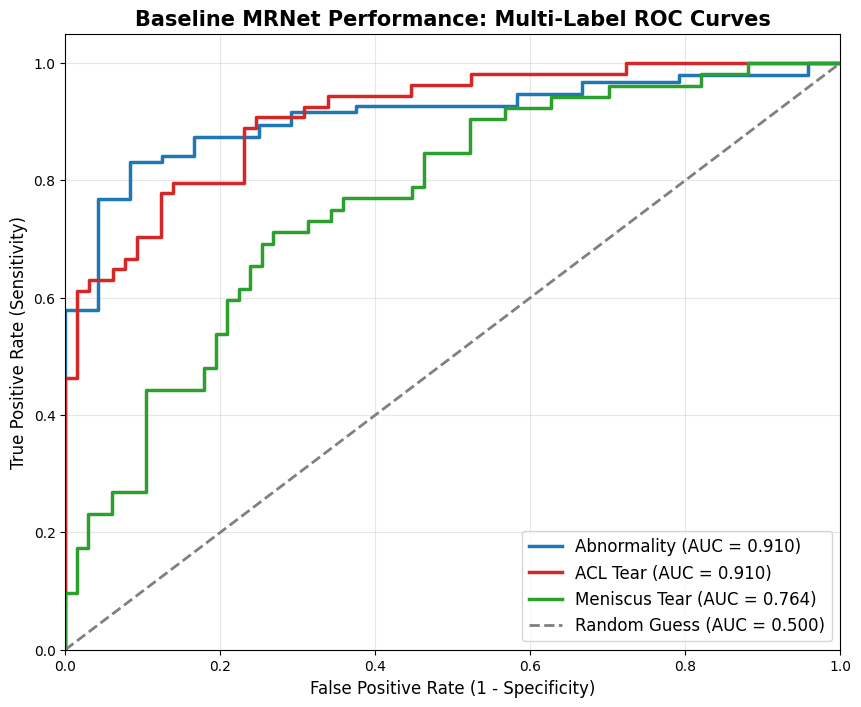

In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import numpy as np
import torch

def evaluate_and_plot_roc(model, data_loader, device, model_path):
    print("Loading best model weights for evaluation...")
    model.load_state_dict(torch.load(model_path, map_location=device, weights_only=True))
    model.eval()
    
    all_preds = []
    all_labels = []
    
    print("Running inference on validation set...")
    with torch.no_grad():
        for volumes, labels in data_loader:
            volumes = volumes.to(device)
            # Forward pass
            logits = model(volumes)
            # Convert to probabilities
            probs = torch.sigmoid(logits)
            
            all_preds.append(probs.cpu().numpy())
            all_labels.append(labels.numpy())
            
    # Stack into numpy arrays
    all_preds = np.vstack(all_preds)
    all_labels = np.vstack(all_labels)
    
    # --- PLOTTING THE ROC CURVES ---
    conditions = ['Abnormality', 'ACL Tear', 'Meniscus Tear']
    colors = ['#1f77b4', '#d62728', '#2ca02c'] # Professional Blue, Red, Green
    
    plt.figure(figsize=(10, 8))
    
    # Calculate and plot the curve for each of the 3 conditions
    for i in range(3):
        # roc_curve calculates the exact False Positive and True Positive rates
        fpr, tpr, _ = roc_curve(all_labels[:, i], all_preds[:, i])
        
        # Calculate the Area Under the Curve (AUC)
        roc_auc = auc(fpr, tpr)
        
        # Plot the line
        plt.plot(fpr, tpr, color=colors[i], lw=2.5, 
                 label=f'{conditions[i]} (AUC = {roc_auc:.3f})')

    # Plot the random guess baseline (a 50/50 coin flip)
    plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random Guess (AUC = 0.500)')
    
    # Graph Formatting
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
    plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)
    plt.title('Baseline MRNet Performance: Multi-Label ROC Curves', fontsize=15, fontweight='bold')
    plt.legend(loc="lower right", fontsize=12)
    plt.grid(alpha=0.3)
    
    plt.show()

# Execute the function
evaluate_and_plot_roc(
    model=model, 
    data_loader=valid_loader, 
    device=device, 
    model_path='/content/CNN_ClassModeling/mrnet_baseline_best.pth'
)

### The Evaluation Metric (How we measure "Success")

Since we only roughly 20% of our training exams have an ACL tear.

If we use standard Accuracy as our metric, the neural network will quickly realize a lazy cheat code: If I just predict "0" (No ACL Tear) for every single patient, I will be 80% accurate! The model will look fantastic on paper, but it will miss every single torn ACL in the hospital. To prevent this, we cannot use Accuracy. We will track the AUC-ROC (Area Under the Receiver Operating Characteristic Curve) and the Validation Loss.

- AUC measures the model's ability to rank a sick patient higher than a healthy patient, regardless of the class imbalance. An AUC of 0.50 means it is guessing; an AUC of 1.0 means perfect clinical separation.

In [16]:
from google.colab import drive
drive.mount('/content/drive')
!cp /content/CNN_ClassModeling/mrnet_baseline_best.pth /content/drive/MyDrive/

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
